In [205]:
import pandas as pd
import numpy as np

In [4]:
df=pd.read_csv('Zoo.csv')

In [6]:
df.head()

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [10]:
df.isnull().sum()

animal name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
type           0
dtype: int64

In [18]:
numeric_df = df.select_dtypes(include='number')

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = (numeric_df < lower) | (numeric_df > upper)
print(outliers.sum())


hair         0
feathers    20
eggs         0
milk         0
airborne    24
aquatic      0
predator     0
toothed      0
backbone    18
breathes    21
venomous     8
fins        17
legs         2
tail         0
domestic    13
catsize      0
type         0
dtype: int64


In [20]:
df_cap = numeric_df.clip(lower=lower, upper=upper, axis=1)


In [22]:
df_cap.head()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,0,0,1,0,0,1,1,1,1,1,0,0,0,1,0,0,4
3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [26]:
outliers_after = (df_cap < lower) | (df_cap > upper)

print("Outliers after capping:")
print(outliers_after.sum())


Outliers after capping:
hair        0
feathers    0
eggs        0
milk        0
airborne    0
aquatic     0
predator    0
toothed     0
backbone    0
breathes    0
venomous    0
fins        0
legs        0
tail        0
domestic    0
catsize     0
type        0
dtype: int64


In [36]:
df_cap['animal name'] = df['animal name']


In [38]:
df_cap.head()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type,animal name
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1,aardvark
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1,antelope
2,0,0,1,0,0,1,1,1,1,1,0,0,0,1,0,0,4,bass
3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1,bear
4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1,boar


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

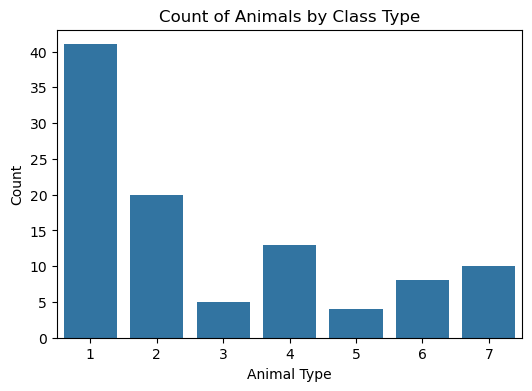

In [79]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df_cap)
plt.title("Count of Animals by Class Type")
plt.xlabel("Animal Type")
plt.ylabel("Count")
plt.show()


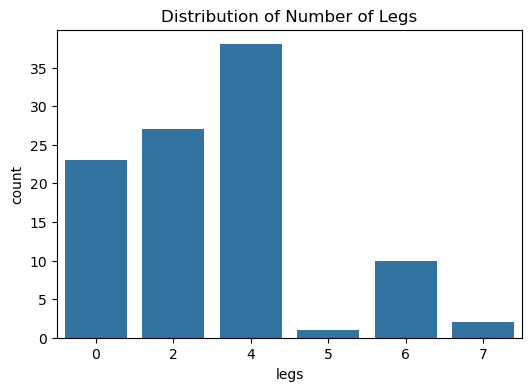

In [81]:
plt.figure(figsize=(6,4))
sns.countplot(x='legs', data=df_cap)
plt.title("Distribution of Number of Legs")
plt.show()


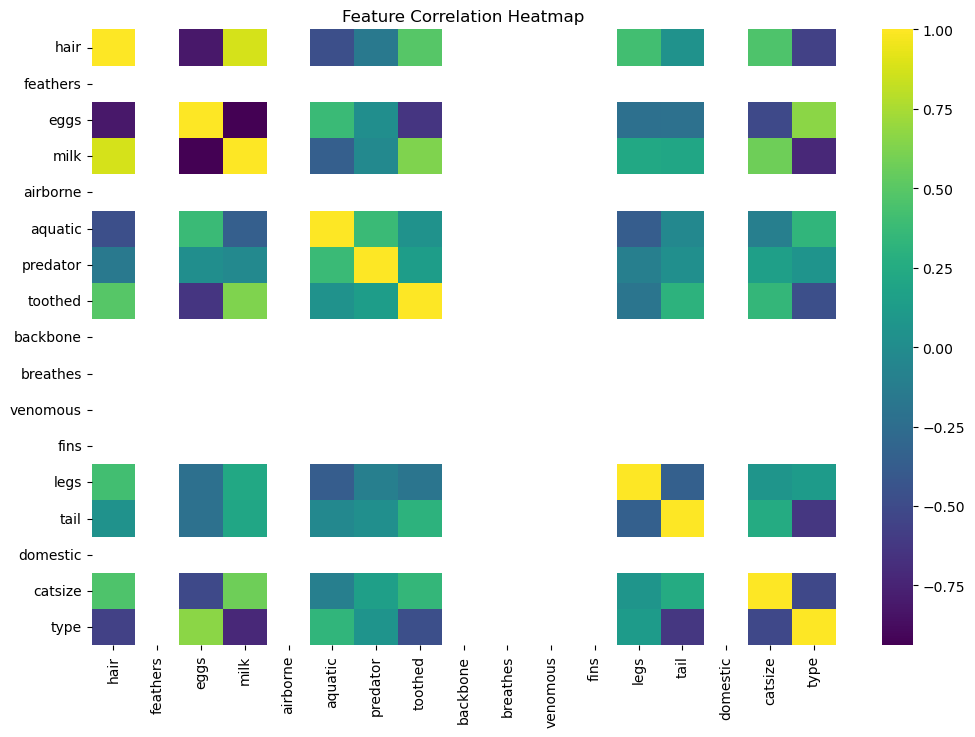

In [83]:
plt.figure(figsize=(12,8))
sns.heatmap(df_cap.drop(columns=['animal name']).corr(), annot=False, cmap='viridis')
plt.title("Feature Correlation Heatmap")
plt.show()


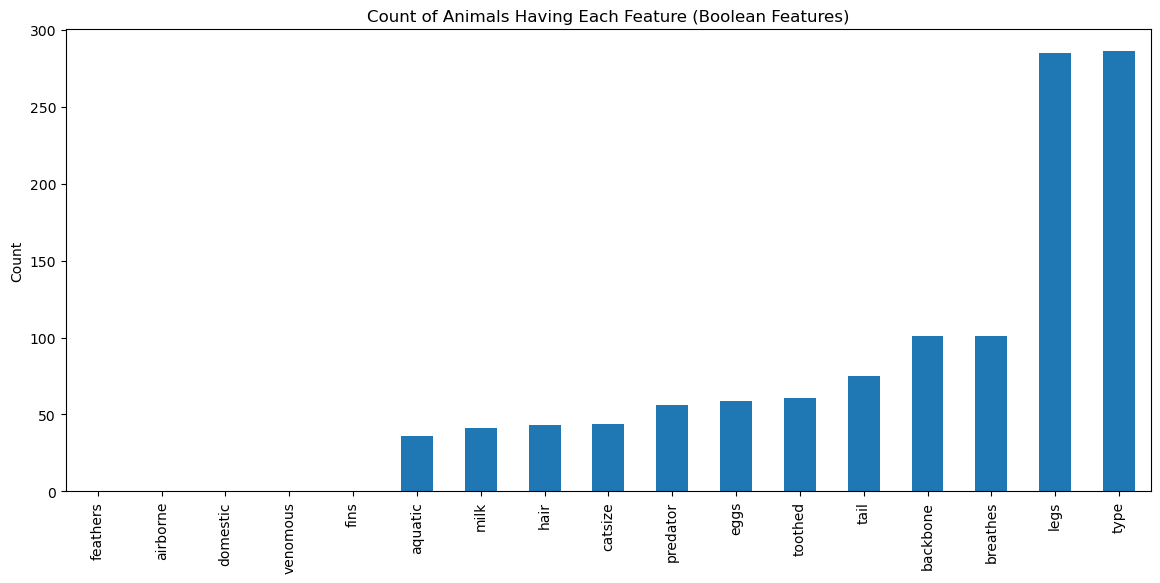

In [85]:
feature_cols = df_cap.columns[:-1]  # all except animal name

plt.figure(figsize=(14,6))
df_cap[feature_cols].sum().sort_values().plot(kind='bar')
plt.title("Count of Animals Having Each Feature (Boolean Features)")
plt.ylabel("Count")
plt.show()


In [87]:
df_cap.head()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type,animal name
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1,aardvark
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1,antelope
2,0,0,1,0,0,1,1,1,1,1,0,0,0,1,0,0,4,bass
3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1,bear
4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1,boar


In [159]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.preprocessing import StandardScaler

In [161]:
X = df_cap.drop(columns=['animal name', 'type'])   # numeric features only
y = df_cap['type']


In [163]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [173]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [193]:
knn=KNeighborsClassifier(n_neighbors=5,metric='minkowski', p=2)

In [195]:
knn.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [197]:
y_pred=knn.predict(X_test_scaled)

In [199]:
print("Accuracy Score:",accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted', zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted', zero_division=0))


Accuracy Score: 0.9523809523809523
Precision: 0.9206349206349207
Recall: 0.9523809523809523
F1 Score: 0.9333333333333333


In [201]:
from sklearn.decomposition import PCA

# Reduce features to 2D
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train new KNN on 2D PCA data
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)


KNeighborsClassifier()

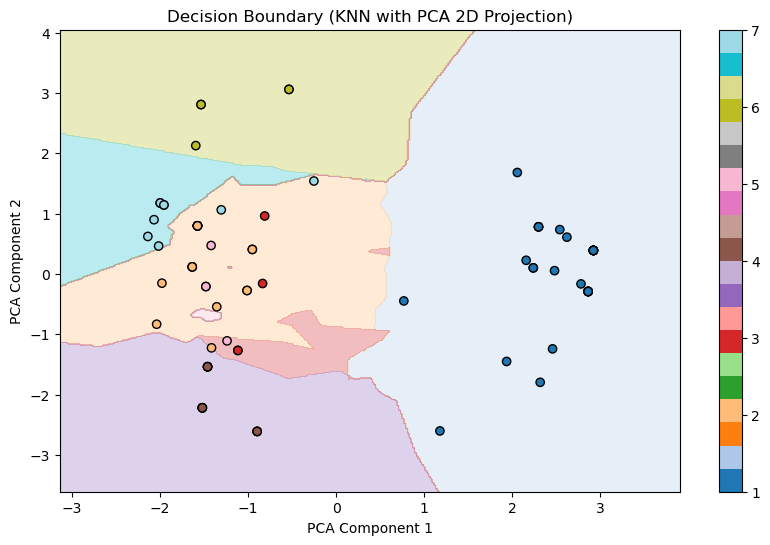

In [207]:
# Create mesh grid
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='tab20')

# Plot points
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                      c=y_train, cmap='tab20', edgecolor='k')

plt.title("Decision Boundary (KNN with PCA 2D Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter)
plt.show()


##  Interview Questions

**Q)What are the key hyperparameters in KNN?**

- **Number of Neighbors (k)** : determines how many nearest data points are considered.
- **Distance Metric** : defines how distance is calculated between points.
- **Weights** : decides whether all neighbors contribute equally or closer ones have more influence.

**Q) What distance metrics can be used in KNN?**

- **Euclidean distance**: Straight-line distance between two points in space.
- **Manhattan distance**: Distance measured as the sum of absolute differences along axes.
- **Minkowski distance**: Generalized distance metric that includes Euclidean and Manhattan.
- **Cosine similarity**: Measures the angle between vectors, focusing on direction not magnitude.
- **Hamming distance**: Counts the number of positions where values differ (categorical/binary data).
